# Skin AMP discovery (SVM)

Join a sequences CSV (`id`, `gene`, `name`, `sequence`) with an `svm_predict.py` output and:

- plot **P(AMP)** and **hyperplane-distance** distributions (same style as `model_prediction_analysis.ipynb`)
- plot hyperplane-distance for peptides with **P(AMP) > 0.9** only
- plot the same scores **by single-cell expression cluster**
- annotate **labeled** proteins by **name** (not id)
- print the **top 20** candidates by SVM score

Edit paths and `HIGHLIGHTED_NAMES` in the next cell, then run all.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import gaussian_kde

PROJECT_ROOT = Path("../sequence_to_svm_minimal").expanduser().resolve()

# --- edit these paths (relative to PROJECT_ROOT unless absolute) ---
SEQUENCES_CSV = "data/test/amp_discovery/sequences.csv"
SVM_PREDICTIONS_CSV = "data/test/amp_discovery/generated/svm_predictions.csv"

DATASET_NAME = "Skin proteome AMP discovery"

# Rank by this score for the top-N table.
# Options: "SVM_prob_AMP" or "SVM_hyperplane_distance"
RANK_BY = "SVM_prob_AMP"
TOP_N = 20

# Label specific proteins on the plots (matched case-insensitively).
# Keys may be protein name, gene token (e.g. A2MG_HUMAN), full gene field,
# peptide id (seq_0001), or exact sequence. Values are the plot labels.
HIGHLIGHTED_NAMES = {
    # "Alpha-2-macroglobulin": "A2M",
    # "A2MG_HUMAN": "A2M",
}

PLOT_STYLE = "seaborn-v0_8-whitegrid"
N_BINS = 100
plt.style.use(PLOT_STYLE)
SVM_COLOR = plt.rcParams["axes.prop_cycle"].by_key()["color"][0]

## Helpers

In [2]:
def _resolve(path_str: str) -> Path:
    raw = Path(path_str).expanduser()
    if raw.is_absolute():
        candidates = [raw]
    else:
        candidates = [
            PROJECT_ROOT / raw,
            Path.cwd() / raw,
            Path.cwd() / "notebooks" / raw,
        ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(f"File not found: {path_str}")


def _find_column(frame: pd.DataFrame, names: list[str]) -> str | None:
    by_lower = {c.lower(): c for c in frame.columns}
    for name in names:
        if name.lower() in by_lower:
            return by_lower[name.lower()]
    return None


def _norm_text(value) -> str:
    if pd.isna(value):
        return ""
    return str(value).strip()


def _norm_key(value) -> str:
    return _norm_text(value).casefold()


def _norm_seq(value) -> str:
    return _norm_text(value).upper()


def _gene_token(gene: str) -> str:
    g = _norm_text(gene)
    if not g:
        return ""
    return g.split("|")[-1]


def _rename_optional(frame: pd.DataFrame, wanted: str) -> pd.DataFrame:
    found = _find_column(frame, [wanted])
    if found and found != wanted:
        return frame.rename(columns={found: wanted})
    return frame


def load_joined_table() -> pd.DataFrame:
    seq_path = _resolve(SEQUENCES_CSV)
    pred_path = _resolve(SVM_PREDICTIONS_CSV)

    sequences = pd.read_csv(seq_path)
    preds = pd.read_csv(pred_path)

    seq_id = _find_column(sequences, ["id", "peptide_id"])
    pred_id = _find_column(preds, ["peptide_id", "id"])
    if seq_id is None or pred_id is None:
        raise ValueError("Both CSVs need an id / peptide_id column.")

    required_pred = ["SVM_prob_AMP", "SVM_hyperplane_distance"]
    missing = [c for c in required_pred if c not in preds.columns]
    if missing:
        raise ValueError(f"Prediction CSV missing columns: {missing}")

    sequences = sequences.rename(columns={seq_id: "id"})
    for col in ("gene", "name", "sequence", "single_cell_expression_cluster"):
        sequences = _rename_optional(sequences, col)

    preds = preds.rename(columns={pred_id: "id"})
    pred_seq = _find_column(preds, ["sequence"])
    if pred_seq and pred_seq != "sequence":
        preds = preds.rename(columns={pred_seq: "sequence_pred"})
    elif pred_seq == "sequence":
        preds = preds.rename(columns={"sequence": "sequence_pred"})

    keep_pred = ["id", "SVM_prob_AMP", "SVM_hyperplane_distance"]
    if "SVM_pred" in preds.columns:
        keep_pred.append("SVM_pred")
    if "sequence_pred" in preds.columns:
        keep_pred.append("sequence_pred")
    preds = preds[keep_pred]

    keep_seq = ["id"] + [
        c
        for c in ("gene", "name", "sequence", "single_cell_expression_cluster")
        if c in sequences.columns
    ]
    sequences = sequences[keep_seq]

    joined = sequences.merge(preds, on="id", how="inner")
    if joined.empty:
        raise ValueError("No overlapping ids between sequences and predictions.")

    if "name" not in joined.columns:
        joined["name"] = ""
    if "gene" not in joined.columns:
        joined["gene"] = ""
    if "sequence" not in joined.columns and "sequence_pred" in joined.columns:
        joined["sequence"] = joined["sequence_pred"]

    joined["display_name"] = joined["name"].map(_norm_text)
    empty_name = joined["display_name"] == ""
    joined.loc[empty_name, "display_name"] = joined.loc[empty_name, "gene"].map(_gene_token)
    still_empty = joined["display_name"] == ""
    joined.loc[still_empty, "display_name"] = joined.loc[still_empty, "id"].astype(str)

    joined["gene_token"] = joined["gene"].map(_gene_token)
    joined["__seq"] = joined["sequence"].map(_norm_seq) if "sequence" in joined.columns else ""
    joined["SVM_prob_AMP"] = pd.to_numeric(joined["SVM_prob_AMP"], errors="coerce")
    joined["SVM_hyperplane_distance"] = pd.to_numeric(
        joined["SVM_hyperplane_distance"], errors="coerce"
    )

    print(f"Sequences:   {seq_path} ({len(sequences):,} rows)")
    print(f"Predictions: {pred_path} ({len(preds):,} rows)")
    print(f"Joined:      {len(joined):,} rows")
    return joined


def _build_index_lists(values, normalizer) -> dict[str, list[int]]:
    out: dict[str, list[int]] = {}
    for i, value in enumerate(values):
        key = normalizer(value)
        if not key:
            continue
        out.setdefault(key, []).append(i)
    return out


def _highlight_lookup(frame: pd.DataFrame) -> dict[str, list[int]]:
    if not HIGHLIGHTED_NAMES:
        return {}

    index_maps = [
        _build_index_lists(frame["display_name"], _norm_key),
        _build_index_lists(frame["gene"], _norm_key),
        _build_index_lists(frame["gene_token"], _norm_key),
        _build_index_lists(frame["id"], _norm_key),
        _build_index_lists(frame["__seq"], _norm_seq),
    ]

    found: dict[str, list[int]] = {}
    missing = []
    for key, label in HIGHLIGHTED_NAMES.items():
        key_text = _norm_text(key)
        if not key_text:
            continue
        hits = []
        for mapping in index_maps:
            for lookup in (_norm_key(key_text), _norm_seq(key_text)):
                if lookup in mapping:
                    hits = mapping[lookup]
                    break
            if hits:
                break
        if not hits:
            missing.append(key_text)
            continue
        found.setdefault(str(label), []).extend(hits)

    print(f"Highlighted labels resolved: {len(found)}/{len(HIGHLIGHTED_NAMES)}")
    if missing:
        print("Not found:", ", ".join(missing))
    return found


def _finite(series: pd.Series) -> np.ndarray:
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    return values[np.isfinite(values)]


def distribution_xlim(values: np.ndarray, highlights: list[float], bounded=None):
    low, high = np.nanpercentile(values, [1, 99])
    if highlights:
        low = min(low, min(highlights))
        high = max(high, max(highlights))
    pad = 0.05 * (high - low) if high > low else 1.0
    limits = (float(low - pad), float(high + pad))
    if bounded:
        limits = (max(bounded[0], limits[0]), min(bounded[1], limits[1]))
    return limits


def _kde_counts(values, xs, bin_width, log_y=False):
    if len(values) < 5 or np.unique(values).size < 2:
        return None
    try:
        density = gaussian_kde(values)(xs) * len(values) * bin_width
    except (np.linalg.LinAlgError, ValueError):
        return None
    return np.maximum(density, 1e-6) if log_y else density


def draw_svm_distribution(
    ax,
    values: np.ndarray,
    title: str,
    xlabel: str,
    xlim,
    highlight_points: list[tuple[float, str]],
    threshold=None,
    log_y=False,
):
    bins = np.linspace(xlim[0], xlim[1], N_BINS + 1)
    bin_width = bins[1] - bins[0]
    xs = np.linspace(xlim[0], xlim[1], 512)

    ax.hist(
        values,
        bins=bins,
        color=SVM_COLOR,
        edgecolor=SVM_COLOR,
        alpha=0.20,
        linewidth=0.4,
        zorder=1,
    )
    density = _kde_counts(values, xs, bin_width, log_y)
    if density is not None:
        ax.plot(
            xs,
            density,
            color=SVM_COLOR,
            linewidth=2,
            label=f"SVM (n={len(values):,})",
            zorder=3,
        )
        curve_xs, curve_ys = xs, density
    else:
        ax.plot([], [], color=SVM_COLOR, linewidth=2, label=f"SVM (n={len(values):,})")
        curve_xs = curve_ys = None

    if threshold is not None:
        ax.axvline(
            threshold,
            color="black",
            linewidth=1,
            alpha=0.65,
            label=f"Threshold {threshold:g}",
            zorder=2,
        )

    for i, (x_value, label) in enumerate(highlight_points):
        y_value = (
            float(np.interp(x_value, curve_xs, curve_ys))
            if curve_xs is not None
            else 1.0
        )
        if log_y:
            y_value = max(y_value, 1e-3)
        ax.scatter(
            x_value,
            y_value,
            marker="D",
            s=34,
            color=SVM_COLOR,
            edgecolor="white",
            linewidth=0.5,
            zorder=5,
        )
        side = -1 if i % 2 else 1
        tier = i % 4
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(side * (8 + 4 * tier), 14 + 9 * tier),
            textcoords="offset points",
            ha="left" if side > 0 else "right",
            fontsize=7,
            color=SVM_COLOR,
            arrowprops={"arrowstyle": "-", "color": SVM_COLOR, "lw": 0.7},
            zorder=6,
        )

    ax.set(xlim=xlim, xlabel=xlabel, ylabel="Peptide count", title=title)
    if log_y:
        ax.set_yscale("log")
    ax.legend(loc="best", fontsize=8)


def highlight_points_for(frame: pd.DataFrame, column: str, lookup: dict[str, list[int]]):
    points = []
    for label, indices in lookup.items():
        for idx in indices:
            value = frame.iloc[idx][column]
            if pd.notna(value) and np.isfinite(float(value)):
                points.append((float(value), label))
    return points

## Load & join

In [3]:
df = load_joined_table()
highlight_lookup = _highlight_lookup(df)
preview_cols = [
    "id",
    "gene",
    "display_name",
    "SVM_prob_AMP",
    "SVM_hyperplane_distance",
]
if "single_cell_expression_cluster" in df.columns:
    preview_cols.insert(3, "single_cell_expression_cluster")
display(df[preview_cols].head())

Sequences:   /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/data/test/amp_discovery/sequences.csv (4,614 rows)
Predictions: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/data/test/amp_discovery/generated/svm_predictions.csv (4,614 rows)
Joined:      4,614 rows


,id,gene,display_name,single_cell_expression_cluster,SVM_prob_AMP,SVM_hyperplane_distance
0,seq_0001,sp|P04217|A1BG_HUMAN,Alpha-1B-glycoprotein,Cluster 80: Oligodendrocytes - Myelination,0.076004,-1.403072
1,seq_0002,sp|P01023|A2MG_HUMAN,Alpha-2-macroglobulin,Cluster 25: Hepatocytes - Plasma protein synth...,0.808405,0.890488
2,seq_0003,sp|A8K2U0|A2ML1_HUMAN,Alpha-2-macroglobulin-like protein 1,Cluster 49: Apical squamous epithelium - Epith...,0.029275,-2.002520
3,seq_0004,sp|Q86V21|AACS_HUMAN,Acetoacetyl-CoA synthetase,Cluster 35: Neurons - Synaptic function & neur...,0.552548,0.174756
4,seq_0005,sp|Q6PD74|AAGAB_HUMAN,Alpha- and gamma-adaptin-binding protein p34,Cluster 7: Non-specific - Transcription,0.200281,-0.754510


## Distributions

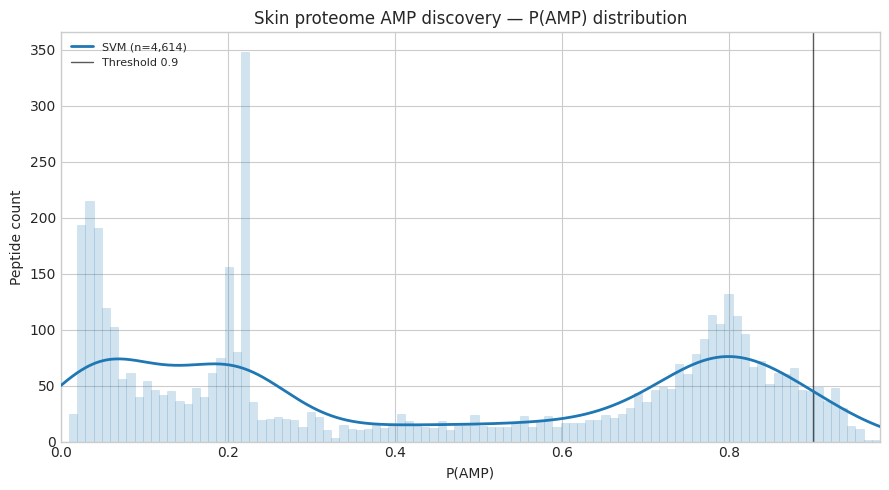

In [4]:
prob_values = _finite(df["SVM_prob_AMP"])
prob_highlights = highlight_points_for(df, "SVM_prob_AMP", highlight_lookup)
prob_xlim = distribution_xlim(
    prob_values, [x for x, _ in prob_highlights], bounded=(0.0, 1.0)
)

fig, ax = plt.subplots(figsize=(9, 5))
draw_svm_distribution(
    ax,
    prob_values,
    f"{DATASET_NAME} — P(AMP) distribution",
    "P(AMP)",
    prob_xlim,
    prob_highlights,
    threshold=0.9,
)
fig.tight_layout()
plt.show()

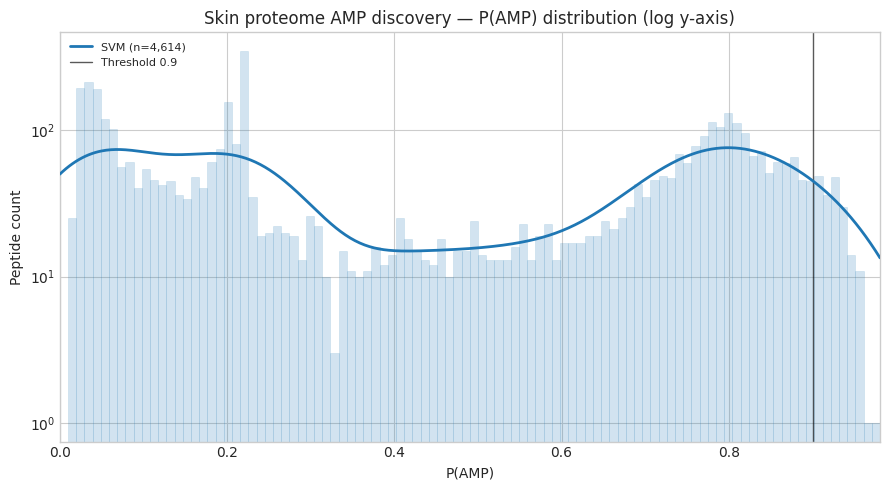

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
draw_svm_distribution(
    ax,
    prob_values,
    f"{DATASET_NAME} — P(AMP) distribution (log y-axis)",
    "P(AMP)",
    prob_xlim,
    prob_highlights,
    threshold=0.9,
    log_y=True,
)
fig.tight_layout()
plt.show()

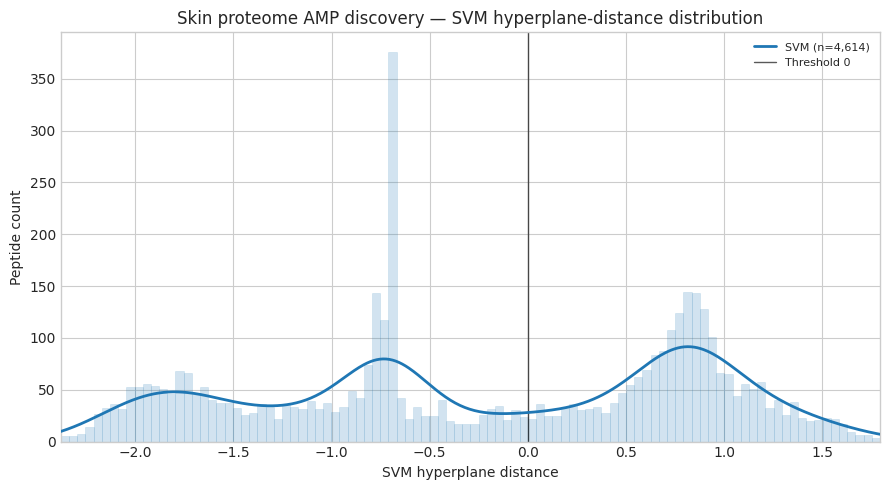

In [6]:
dist_values = _finite(df["SVM_hyperplane_distance"])
dist_highlights = highlight_points_for(df, "SVM_hyperplane_distance", highlight_lookup)
dist_xlim = distribution_xlim(dist_values, [x for x, _ in dist_highlights])

fig, ax = plt.subplots(figsize=(9, 5))
draw_svm_distribution(
    ax,
    dist_values,
    f"{DATASET_NAME} — SVM hyperplane-distance distribution",
    "SVM hyperplane distance",
    dist_xlim,
    dist_highlights,
    threshold=0.0,
)
fig.tight_layout()
plt.show()

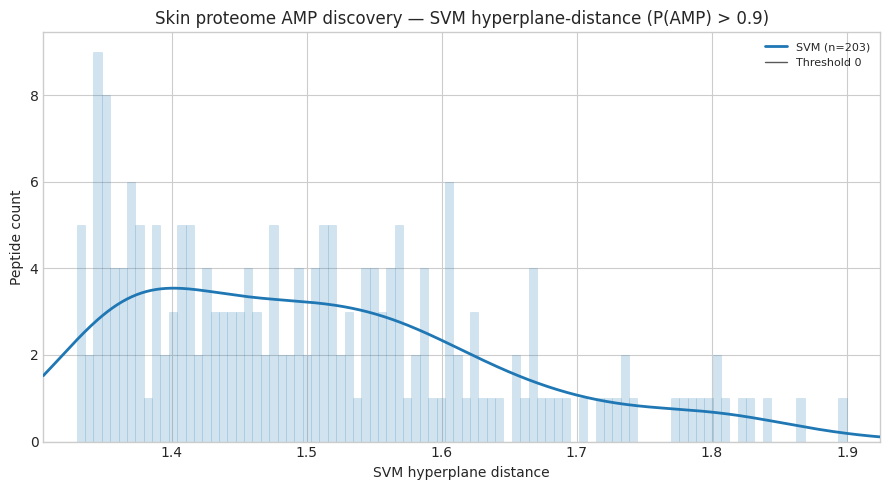

In [7]:
# Hyperplane distance for high-confidence AMP calls only (P > 0.9)
high_p_mask = df["SVM_prob_AMP"] > 0.9
dist_p09_values = _finite(df.loc[high_p_mask, "SVM_hyperplane_distance"])
dist_p09_lookup = {
    label: [
        i
        for i in indices
        if pd.notna(df.iloc[i]["SVM_prob_AMP"])
        and float(df.iloc[i]["SVM_prob_AMP"]) > 0.9
    ]
    for label, indices in highlight_lookup.items()
}
dist_p09_highlights = highlight_points_for(
    df, "SVM_hyperplane_distance", dist_p09_lookup
)
dist_p09_xlim = distribution_xlim(
    dist_p09_values, [x for x, _ in dist_p09_highlights]
)

fig, ax = plt.subplots(figsize=(9, 5))
draw_svm_distribution(
    ax,
    dist_p09_values,
    f"{DATASET_NAME} — SVM hyperplane-distance (P(AMP) > 0.9)",
    "SVM hyperplane distance",
    dist_p09_xlim,
    dist_p09_highlights,
    threshold=0.0,
)
fig.tight_layout()
plt.show()


## Distributions by expression cluster

Same SVM scores as above, split by `single_cell_expression_cluster` (Human Protein Atlas). Overlay KDEs for the largest clusters; boxplots and the summary table include **all** clusters, sorted by median P(AMP).


Expression clusters: 110 non-empty (+ 13 missing); 4,601 / 4,614 annotated


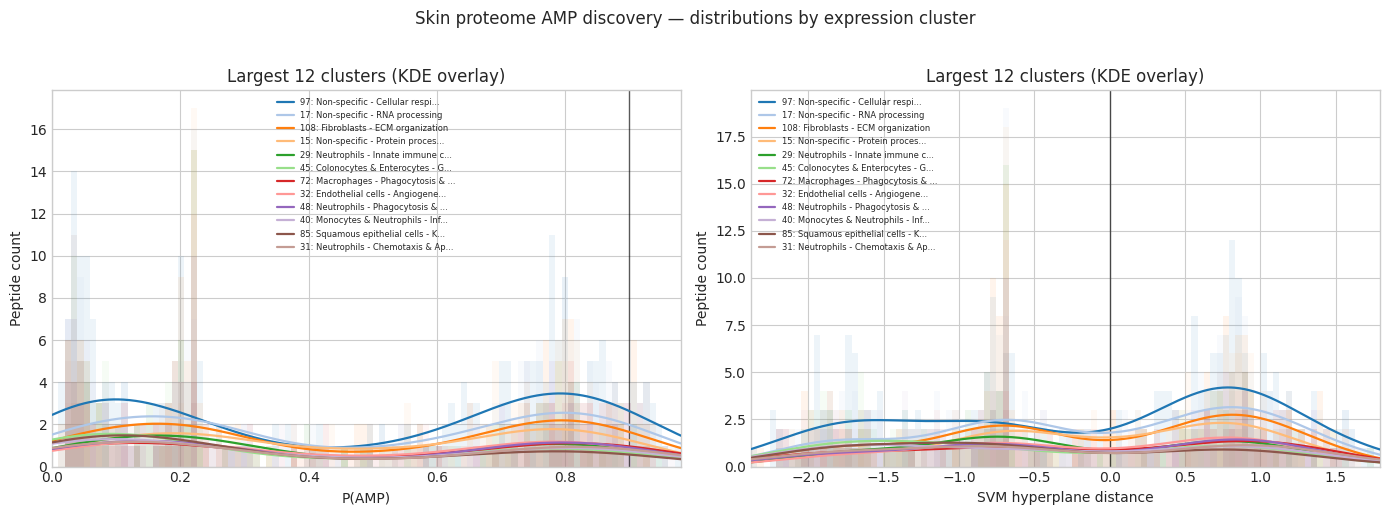

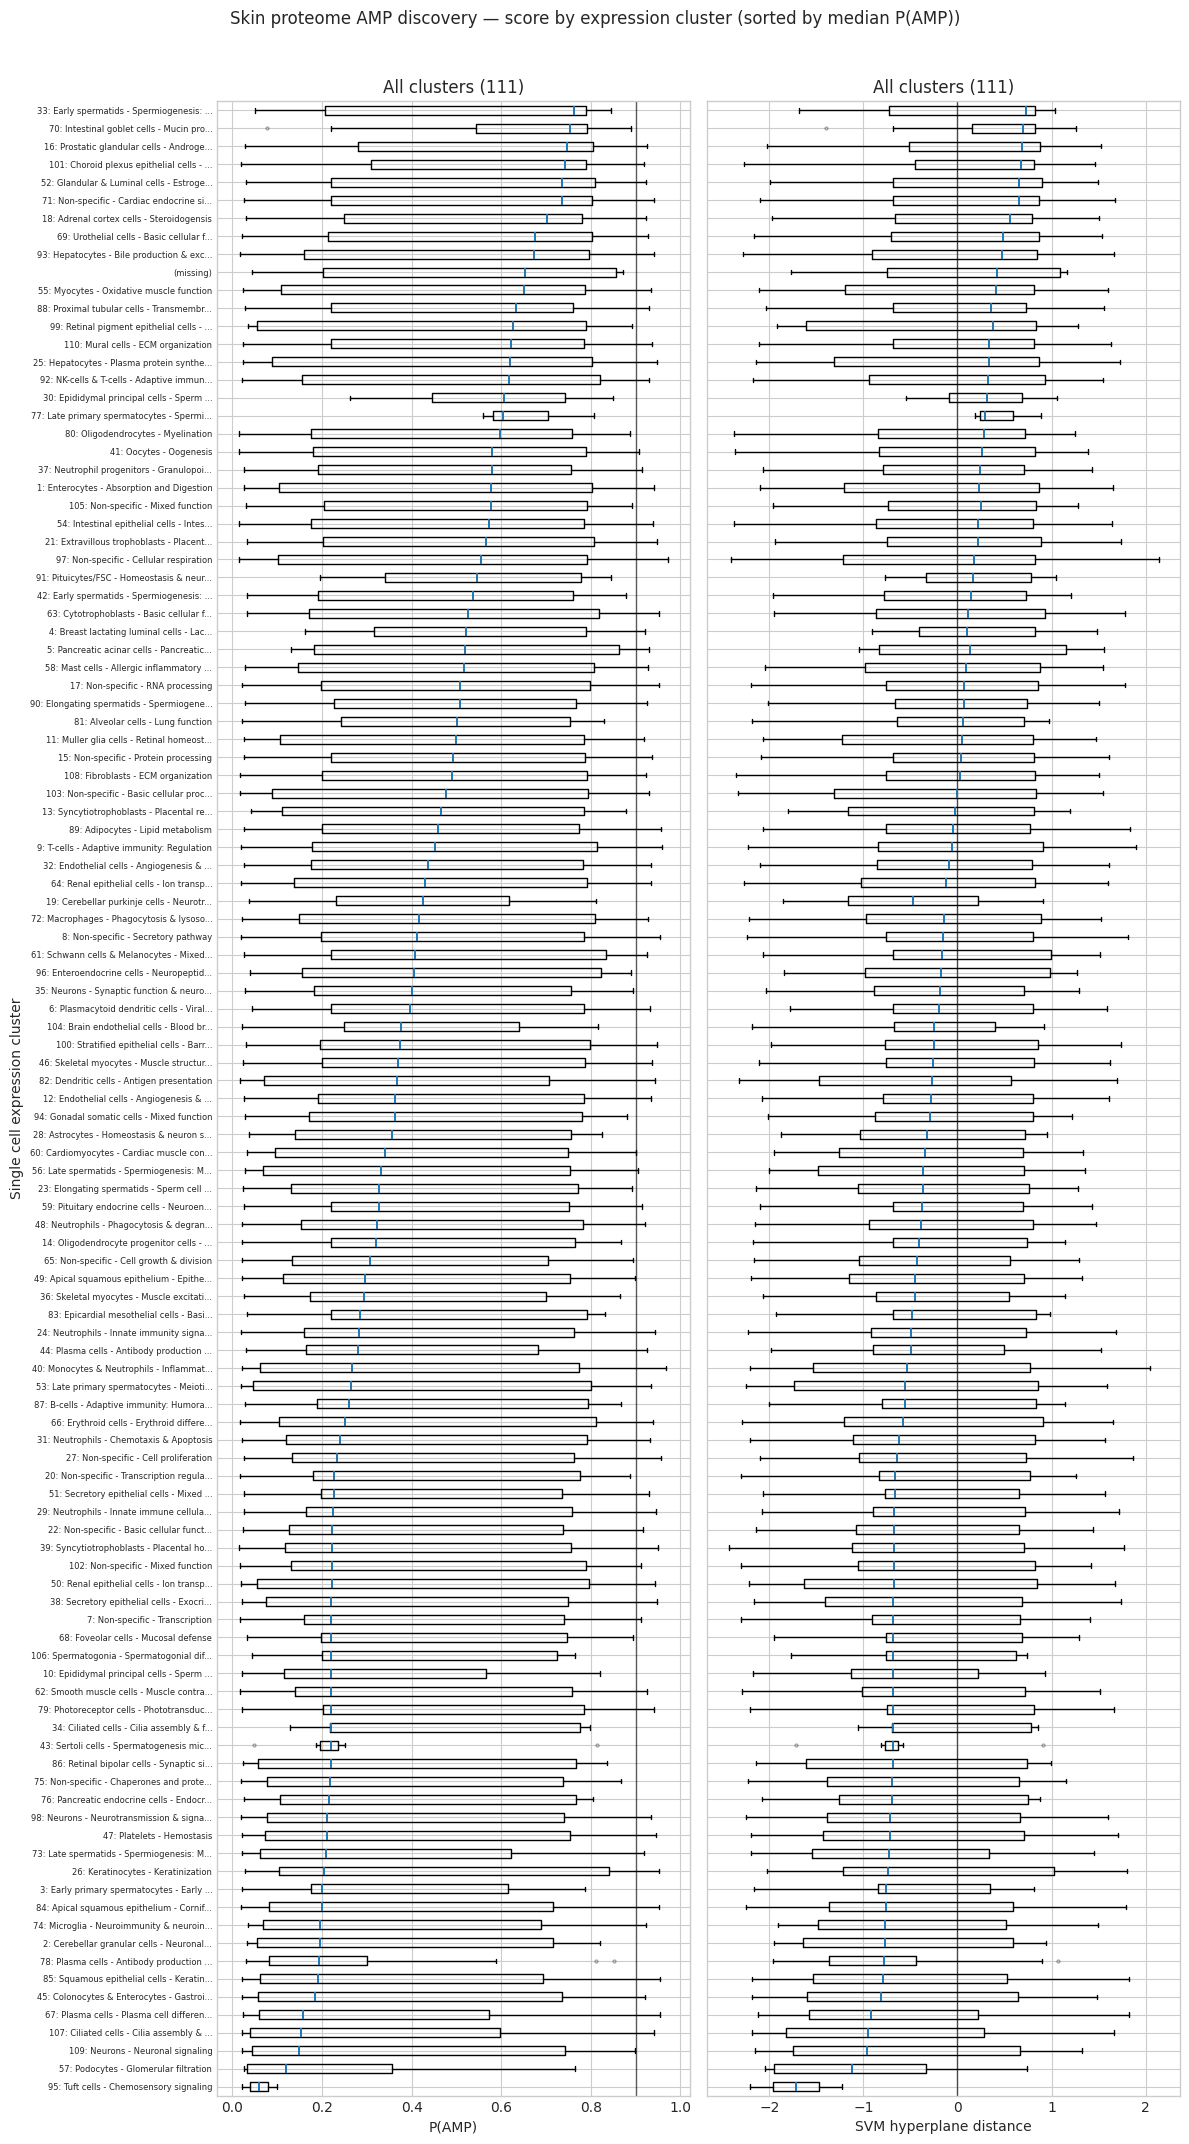

Cluster summary (111 groups), highest median P(AMP) first:


,single_cell_expression_cluster,n,median_P_AMP,frac_P_gt_0_9,median_distance
0,Cluster 33: Early spermatids - Spermiogenesis:...,17,0.761393,0.000000,0.727909
1,Cluster 70: Intestinal goblet cells - Mucin pr...,16,0.752837,0.000000,0.700811
2,Cluster 16: Prostatic glandular cells - Androg...,18,0.746902,0.166667,0.683580
3,Cluster 101: Choroid plexus epithelial cells -...,14,0.742702,0.071429,0.670320
4,Cluster 52: Glandular & Luminal cells - Estrog...,25,0.736482,0.040000,0.650703
...,...,...,...,...,...
106,Cluster 67: Plasma cells - Plasma cell differe...,41,0.158601,0.073171,-0.920024
107,Cluster 107: Ciliated cells - Cilia assembly &...,22,0.152182,0.045455,-0.949797
108,Cluster 109: Neurons - Neuronal signaling,15,0.148377,0.000000,-0.965876
109,Cluster 57: Podocytes - Glomerular filtration,8,0.119450,0.000000,-1.119366


In [8]:
CLUSTER_COL = "single_cell_expression_cluster"
CLUSTER_KDE_TOP_N = 12


def _cluster_label(value) -> str:
    text = _norm_text(value)
    return text if text else "(missing)"


def _short_cluster_label(value: str, max_len: int = 42) -> str:
    text = _cluster_label(value)
    if text.startswith("Cluster "):
        text = text[len("Cluster ") :]
    if len(text) <= max_len:
        return text
    return text[: max_len - 3] + "..."


if CLUSTER_COL not in df.columns:
    raise ValueError(
        f"Missing {CLUSTER_COL!r}; regenerate sequences.csv with convert_fasta.py --annotation-tsv."
    )

clustered = df.copy()
clustered["_cluster"] = clustered[CLUSTER_COL].map(_cluster_label)
cluster_counts = clustered["_cluster"].value_counts()
n_clusters = int(clustered.loc[clustered["_cluster"] != "(missing)", "_cluster"].nunique())
n_missing = int((clustered["_cluster"] == "(missing)").sum())
n_annotated = int((clustered["_cluster"] != "(missing)").sum())
print(
    f"Expression clusters: {n_clusters:,} non-empty"
    f" (+ {n_missing:,} missing); "
    f"{n_annotated:,} / {len(clustered):,} annotated"
)

top_clusters = list(cluster_counts.head(CLUSTER_KDE_TOP_N).index)
cmap = plt.get_cmap("tab20")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, column, xlabel, xlim, threshold in (
    (axes[0], "SVM_prob_AMP", "P(AMP)", prob_xlim, 0.9),
    (axes[1], "SVM_hyperplane_distance", "SVM hyperplane distance", dist_xlim, 0.0),
):
    bins = np.linspace(xlim[0], xlim[1], N_BINS + 1)
    bin_width = bins[1] - bins[0]
    xs = np.linspace(xlim[0], xlim[1], 512)
    for i, cluster in enumerate(top_clusters):
        values = _finite(clustered.loc[clustered["_cluster"] == cluster, column])
        if len(values) < 5:
            continue
        color = cmap(i % 20)
        ax.hist(values, bins=bins, color=color, alpha=0.08, linewidth=0, zorder=1)
        density = _kde_counts(values, xs, bin_width)
        if density is not None:
            ax.plot(
                xs,
                density,
                color=color,
                linewidth=1.6,
                label=_short_cluster_label(cluster, 36),
                zorder=3,
            )
    ax.axvline(threshold, color="black", linewidth=1, alpha=0.65, zorder=2)
    ax.set(
        xlim=xlim,
        xlabel=xlabel,
        ylabel="Peptide count",
        title=f"Largest {len(top_clusters)} clusters (KDE overlay)",
    )
    ax.legend(loc="best", fontsize=6)
fig.suptitle(f"{DATASET_NAME} — distributions by expression cluster", y=1.02)
fig.tight_layout()
plt.show()

medians = (
    clustered.groupby("_cluster")["SVM_prob_AMP"]
    .median()
    .sort_values()
)
order = list(medians.index)
fig, axes = plt.subplots(
    1, 2, figsize=(12, max(8.0, 0.18 * len(order) + 1.2)), sharey=True
)
for ax, column, xlabel, threshold in (
    (axes[0], "SVM_prob_AMP", "P(AMP)", 0.9),
    (axes[1], "SVM_hyperplane_distance", "SVM hyperplane distance", 0.0),
):
    data = [_finite(clustered.loc[clustered["_cluster"] == name, column]) for name in order]
    ax.boxplot(
        data,
        vert=False,
        flierprops={"markersize": 2, "alpha": 0.35},
        medianprops={"color": SVM_COLOR, "linewidth": 1.4},
    )
    ax.set_yticks(range(1, len(order) + 1))
    ax.set_yticklabels([_short_cluster_label(name) for name in order], fontsize=6)
    ax.axvline(threshold, color="black", linewidth=1, alpha=0.65)
    ax.set_xlabel(xlabel)
    ax.set_title(f"All clusters ({len(order)})")
axes[0].set_ylabel("Single cell expression cluster")
fig.suptitle(
    f"{DATASET_NAME} — score by expression cluster (sorted by median P(AMP))",
    y=1.01,
)
fig.tight_layout()
plt.show()

summary = (
    clustered.groupby("_cluster", sort=False)
    .agg(
        n=("id", "size"),
        median_P_AMP=("SVM_prob_AMP", "median"),
        frac_P_gt_0_9=("SVM_prob_AMP", lambda s: (s > 0.9).mean()),
        median_distance=("SVM_hyperplane_distance", "median"),
    )
    .reindex(order[::-1])
    .reset_index()
    .rename(columns={"_cluster": "single_cell_expression_cluster"})
)
print(f"Cluster summary ({len(summary)} groups), highest median P(AMP) first:")
display(summary)


## Top candidates

Names are shown instead of ids. Change `RANK_BY` / `TOP_N` in the config cell to rerank.

In [9]:
if RANK_BY not in {"SVM_prob_AMP", "SVM_hyperplane_distance"}:
    raise ValueError("RANK_BY must be SVM_prob_AMP or SVM_hyperplane_distance")

ranked = (
    df.dropna(subset=[RANK_BY])
    .sort_values(RANK_BY, ascending=False, kind="stable")
    .head(TOP_N)
    .copy()
)
ranked.insert(0, "rank", range(1, len(ranked) + 1))

top_cols = [
    "rank",
    "display_name",
    "gene",
    "id",
    "SVM_prob_AMP",
    "SVM_hyperplane_distance",
    "sequence",
]
if "single_cell_expression_cluster" in ranked.columns:
    top_cols.insert(4, "single_cell_expression_cluster")
top_table = ranked[top_cols].rename(columns={"display_name": "name"})

print(f"Top {TOP_N} by {RANK_BY}:")
display(top_table)

copyable = top_table.copy()
copyable["SVM_prob_AMP"] = copyable["SVM_prob_AMP"].map(lambda x: f"{x:.4f}")
copyable["SVM_hyperplane_distance"] = copyable["SVM_hyperplane_distance"].map(
    lambda x: f"{x:.4f}"
)
print("\nCopyable fixed-width table:\n")
print(f"{'rank':>4}  {'name':<40}  {'P(AMP)':>8}  {'distance':>10}  {'id':<12}")
for row in copyable.to_dict("records"):
    name = (row["name"][:37] + "...") if len(row["name"]) > 40 else row["name"]
    print(
        f"{row['rank']:>4}  {name:<40}  {row['SVM_prob_AMP']:>8}  "
        f"{row['SVM_hyperplane_distance']:>10}  {row['id']:<12}"
    )

Top 20 by SVM_prob_AMP:


,rank,name,gene,id,single_cell_expression_cluster,SVM_prob_AMP,SVM_hyperplane_distance,sequence
2501,1,Small ribosomal subunit protein mS23,sp|Q9Y3D9|RT23_HUMAN,seq_2502,Cluster 97: Non-specific - Cellular respiration,0.972872,2.136967,MAGSRLETVGSIFSRTRDLVRAGVLKEKPLWFDVYDAFPPLREPVF...
3483,2,Rho-related GTP-binding protein RhoG,sp|P84095|RHOG_HUMAN,seq_3484,Cluster 40: Monocytes & Neutrophils - Inflamma...,0.968716,2.051357,MQSIKCVVVGDGAVGKTCLLICYTTNAFPKEYIPTVFDNYSAQSAV...
1558,3,Galactose mutarotase,sp|Q96C23|GALM_HUMAN,seq_1559,Cluster 9: T-cells - Adaptive immunity: Regula...,0.959609,1.896855,MASVTRAVFGELPSGGGTVEKFQLQSDLLRVDIISWGCTITALEVK...
1196,4,Thymidylate kinase,sp|P23919|KTHY_HUMAN,seq_1197,Cluster 27: Non-specific - Cell proliferation,0.957508,1.866000,MAARRGALIVLEGVDRAGKSTQSRKLVEALCAAGHRAELLRFPERS...
3711,5,"Succinate dehydrogenase assembly factor 4, mit...",sp|Q5VUM1|SDHF4_HUMAN,seq_3712,Cluster 89: Adipocytes - Lipid metabolism,0.955588,1.839051,MTPSRLPWLLSWVSATAWRAARSPLLCHSLRKTSSSQGGKSELVKQ...
1945,6,Immunoglobulin heavy constant gamma 1,sp|P01857|IGHG1_HUMAN,seq_1946,Cluster 67: Plasma cells - Plasma cell differe...,0.954615,1.825820,ASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGAL...
3344,7,Partner of Y14 and mago,sp|Q9BRP8|PYM1_HUMAN,seq_3345,Cluster 85: Squamous epithelial cells - Kerati...,0.954141,1.819465,MEAAGSPAATETGKYIASTQRPDGTWRKQRRVKEGYVPQEEVPVYE...
2343,8,Mesencephalic astrocyte-derived neurotrophic f...,sp|P55145|MANF_HUMAN,seq_2344,Cluster 8: Non-specific - Secretory pathway,0.953386,1.809479,MRRMWATQGLAVALALSVLPGSRALRPGDCEVCISYLGRFYQDLKD...
1093,9,Protein DEK,sp|P35659|DEK_HUMAN,seq_1094,Cluster 27: Non-specific - Cell proliferation,0.952926,1.803471,MSASAPAAEGEGTPTQPASEKEPEMPGPREESEEEEDEDDEEEEEE...
1799,10,Adenosine 5'-monophosphoramidase HINT2,sp|Q9BX68|HINT2_HUMAN,seq_1800,Cluster 97: Non-specific - Cellular respiration,0.952868,1.802711,MAAAVVLAAGLRAARRAVAATGVRGGQVRGAAGVTDGNEVAKAQQA...



Copyable fixed-width table:

rank  name                                        P(AMP)    distance  id          
   1  Small ribosomal subunit protein mS23        0.9729      2.1370  seq_2502    
   2  Rho-related GTP-binding protein RhoG        0.9687      2.0514  seq_3484    
   3  Galactose mutarotase                        0.9596      1.8969  seq_1559    
   4  Thymidylate kinase                          0.9575      1.8660  seq_1197    
   5  Succinate dehydrogenase assembly fact...    0.9556      1.8391  seq_3712    
   6  Immunoglobulin heavy constant gamma 1       0.9546      1.8258  seq_1946    
   7  Partner of Y14 and mago                     0.9541      1.8195  seq_3345    
   8  Mesencephalic astrocyte-derived neuro...    0.9534      1.8095  seq_2344    
   9  Protein DEK                                 0.9529      1.8035  seq_1094    
  10  Adenosine 5'-monophosphoramidase HINT2      0.9529      1.8027  seq_1800    
  11  Dermokine                                   0.9526 

## Labeled candidates summary

In [10]:
if not HIGHLIGHTED_NAMES:
    print("Add entries to HIGHLIGHTED_NAMES to see a labeled summary.")
else:
    rows = []
    for key, label in HIGHLIGHTED_NAMES.items():
        indices = highlight_lookup.get(str(label), [])
        if not indices:
            rows.append(
                {
                    "label": label,
                    "query": key,
                    "status": "missing",
                    "name": "",
                    "id": "",
                    "SVM_prob_AMP": np.nan,
                    "SVM_hyperplane_distance": np.nan,
                }
            )
            continue
        for idx in indices:
            row = df.iloc[idx]
            rows.append(
                {
                    "label": label,
                    "query": key,
                    "status": "found",
                    "name": row["display_name"],
                    "id": row["id"],
                    "SVM_prob_AMP": row["SVM_prob_AMP"],
                    "SVM_hyperplane_distance": row["SVM_hyperplane_distance"],
                }
            )
    labeled_summary = pd.DataFrame(rows)
    display(labeled_summary)

Add entries to HIGHLIGHTED_NAMES to see a labeled summary.
